In [1]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [3]:
df.shape

(8807, 12)

In [4]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
df = df.dropna(subset=['country', 'rating', 'date_added'])

df.isnull().sum()

show_id            0
type               0
title              0
director        2214
cast             671
country            0
date_added         0
release_year       0
rating             0
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
df.shape

(7964, 12)

Visualization 1 – Movies vs TV Shows

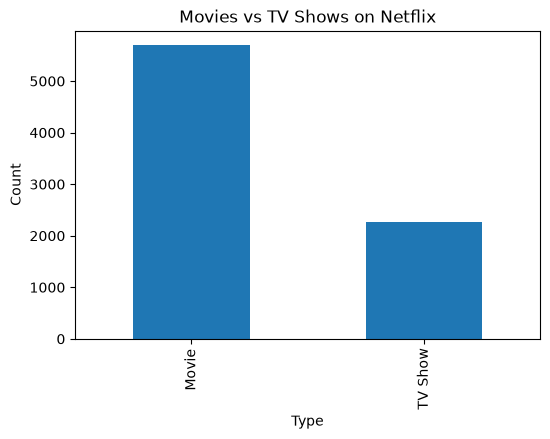

In [7]:
import matplotlib.pyplot as plt

type_counts = df['type'].value_counts()

plt.figure(figsize=(6,4))
type_counts.plot(kind='bar')

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')

plt.show()

Netflix contains significantly more Movies than TV Shows, indicating that movies dominate the platform's content library.

Visualization 2 – Content Added Over the Years

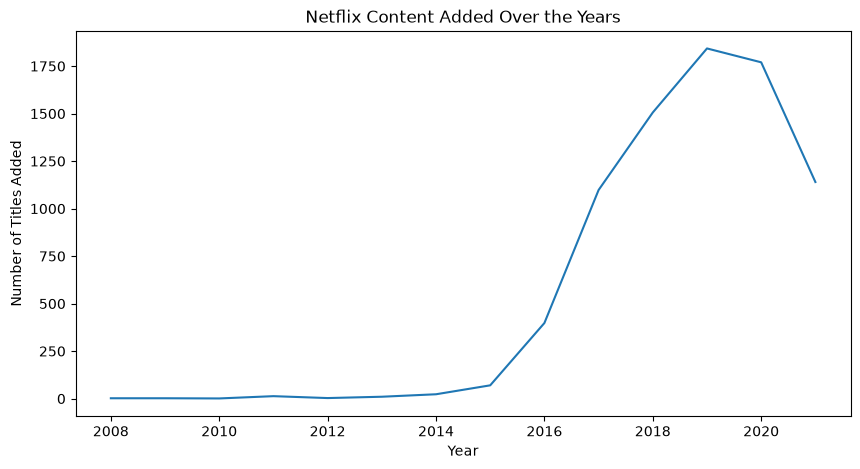

In [8]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['year_added'] = df['date_added'].dt.year

year_counts = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(year_counts.index, year_counts.values)

plt.title('Netflix Content Added Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')

plt.show()

Netflix significantly increased its content additions after 2015, showing rapid platform growth and expansion of its content library.

Visualization 3 – Top 10 Countries Producing Netflix Content

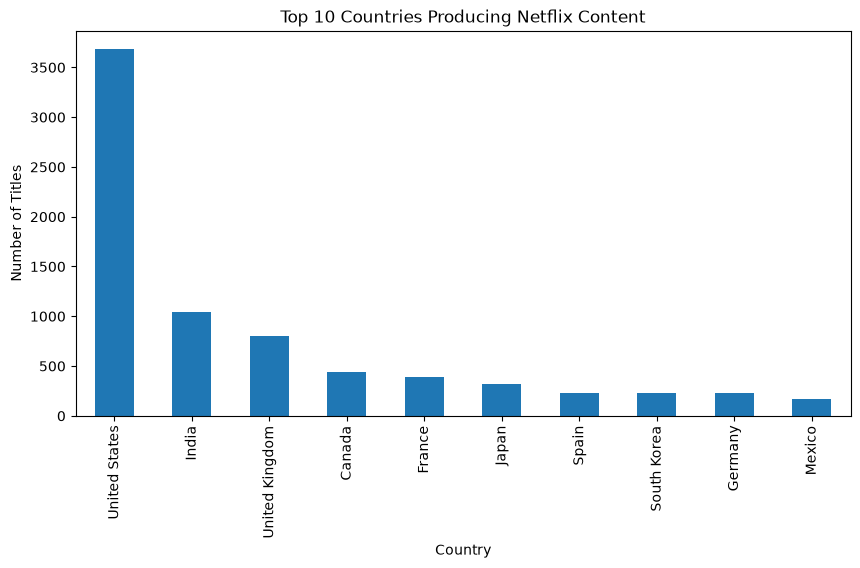

In [9]:
country_counts = df['country'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(10,5))
country_counts.plot(kind='bar')

plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')

plt.show()

The United States contributes the highest number of titles on Netflix, followed by other major content-producing countries such as India and the United Kingdom.

Visualization 4 – Top 10 Most Common Genres

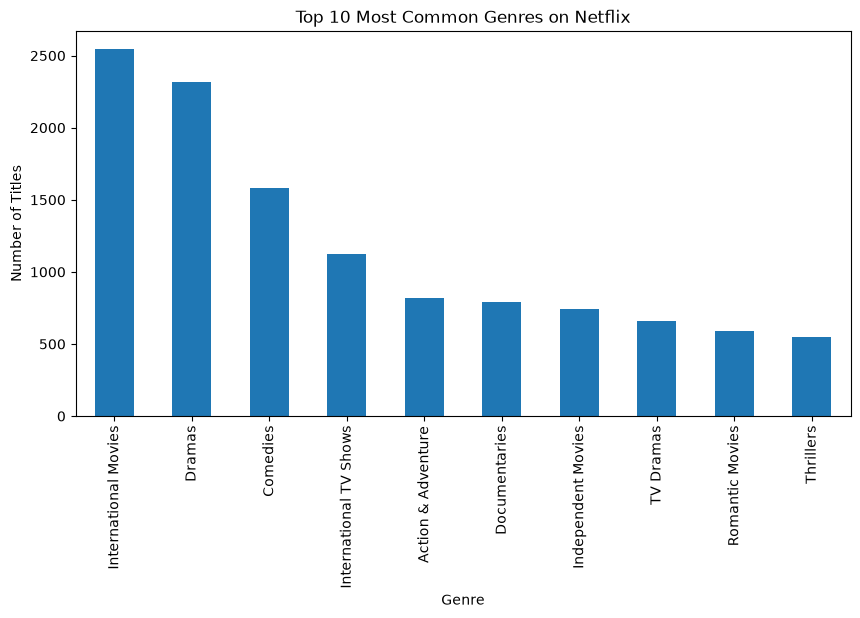

In [10]:
genre_counts = df['listed_in'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(10,5))
genre_counts.plot(kind='bar')

plt.title('Top 10 Most Common Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')

plt.show()

Drama and International content are among the most common genres on Netflix, indicating strong global demand for diverse storytelling.

Visualization 5 – Netflix Content Ratings Distribution

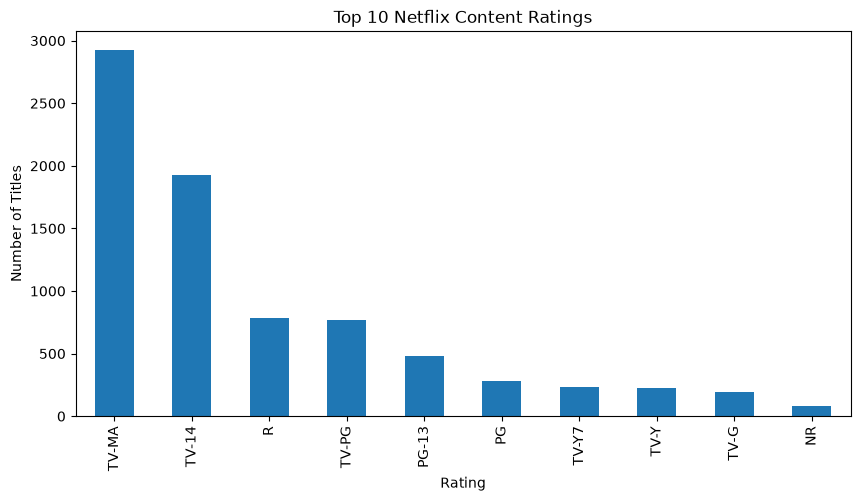

In [11]:
rating_counts = df['rating'].value_counts().head(10)

plt.figure(figsize=(10,5))
rating_counts.plot(kind='bar')

plt.title('Top 10 Netflix Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')

plt.show()

TV-MA and TV-14 are among the most common ratings on Netflix, suggesting that a large portion of the platform's content is targeted toward mature and teenage audiences.

Visualization 6 – Movie Duration Distribution

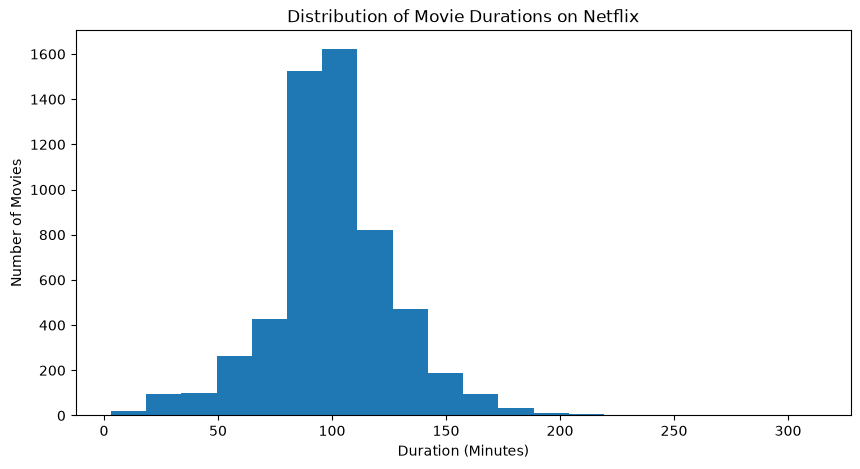

In [12]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration_minutes'] = movies['duration'].str.replace(' min', '', regex=False)
movies['duration_minutes'] = pd.to_numeric(movies['duration_minutes'], errors='coerce')

plt.figure(figsize=(10,5))
plt.hist(movies['duration_minutes'].dropna(), bins=20)

plt.title('Distribution of Movie Durations on Netflix')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')

plt.show()

Most Netflix movies fall between 80 and 120 minutes in duration, indicating a preference for standard feature-length films.

Conclusion

1. Movies dominate Netflix's content library compared to TV Shows.
2. Netflix experienced significant growth in content additions after 2015.
3. The United States is the leading contributor of Netflix content.
4. Drama and International Movies are among the most popular genres.
5. TV-MA and TV-14 are the most common content ratings.
6. Most Netflix movies have durations between 80 and 120 minutes.

These visualizations provide valuable insights into Netflix's content strategy, audience targeting, and global content distribution.